In [1]:
import argparse
import json
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from pathlib import Path

In [5]:
def load_hardware(csv_path: str) -> pd.DataFrame:
    df = pd.read_csv(csv_path)
    df["timestamp"] = pd.to_datetime(df["timestamp"])
    df = df.sort_values("timestamp").reset_index(drop=True)
    return df


def load_pipeline_times(json_path: str) -> dict | None:
    """Load pipeline_start and pipeline_end from eval_results.json, plus per-stage latency info if available."""
    with open(json_path) as f:
        data = json.load(f)
    return {
        "start": pd.to_datetime(data.get("pipeline_start")),
        "end":   pd.to_datetime(data.get("pipeline_end")),
    }


def plot(df: pd.DataFrame, pipeline_times: dict | None, out_path: str):
    # Only plot columns that have actual data
    gpu_cols = {
        "gpu_util_pct":    "GPU Utilisation (%)",
        "gpu_mem_used_mb": "GPU Memory Used (MB)",
        "gpu_mem_free_mb": "GPU Memory Free (MB)",
        "dcgmi_power_w": "DCGM Power (W)",
        "dcgmi_gpu_util_pct": "DCGM GPU Utilisation (%)",
        "dcgmi_nvlink_tx_mbs": "DCGM NVLink TX (MB/s)",
        "dcgmi_nvlink_rx_mbs": "DCGM NVLink RX (MB/s)",
        "dcgmi_pcie_tx_mbs": "DCGM PCIe TX (MB/s)",
        "dcgmi_pcie_rx_mbs": "DCGM PCIe RX (MB/s)"
    }
    available = {k: v for k, v in gpu_cols.items() if k in df.columns and df[k].notna().any()}

    if not available:
        print("No plottable GPU columns found in CSV — all values are empty.")
        return

    n_plots = len(available)
    fig, axes = plt.subplots(n_plots, 1, figsize=(14, 4 * n_plots), sharex=True)
    if n_plots == 1:
        axes = [axes]

    t = df["timestamp"]

    for ax, (col, label) in zip(axes, available.items()):
        ax.plot(t, df[col], linewidth=1.2, color="steelblue")
        ax.set_ylabel(label, fontsize=11)
        ax.grid(True, alpha=0.3)
        ax.set_ylim(bottom=0)

        # ── Pipeline start/end markers ────────────────────────────────
        if pipeline_times:
            if pipeline_times.get("start"):
                ax.axvline(pipeline_times["start"], color="green", linestyle="--",
                           linewidth=1.2, label="Pipeline start")
            if pipeline_times.get("end"):
                ax.axvline(pipeline_times["end"], color="red", linestyle="--",
                           linewidth=1.2, label="Pipeline end")
            ax.legend(fontsize=9, loc="upper right")

    # ── X axis formatting ─────────────────────────────────────────────
    axes[-1].xaxis.set_major_formatter(mdates.DateFormatter("%H:%M:%S"))
    plt.xticks(rotation=30, ha="right")
    axes[-1].set_xlabel("Time", fontsize=11)

    fig.suptitle("Hardware Monitoring — RAG Pipeline Run", fontsize=13, y=1.01)
    plt.tight_layout()

    Path(out_path).parent.mkdir(parents=True, exist_ok=True)
    plt.savefig(out_path, dpi=150, bbox_inches="tight")
    print(f"Saved → {out_path}")
    plt.show()


Saved → plots/hardware_plot.png


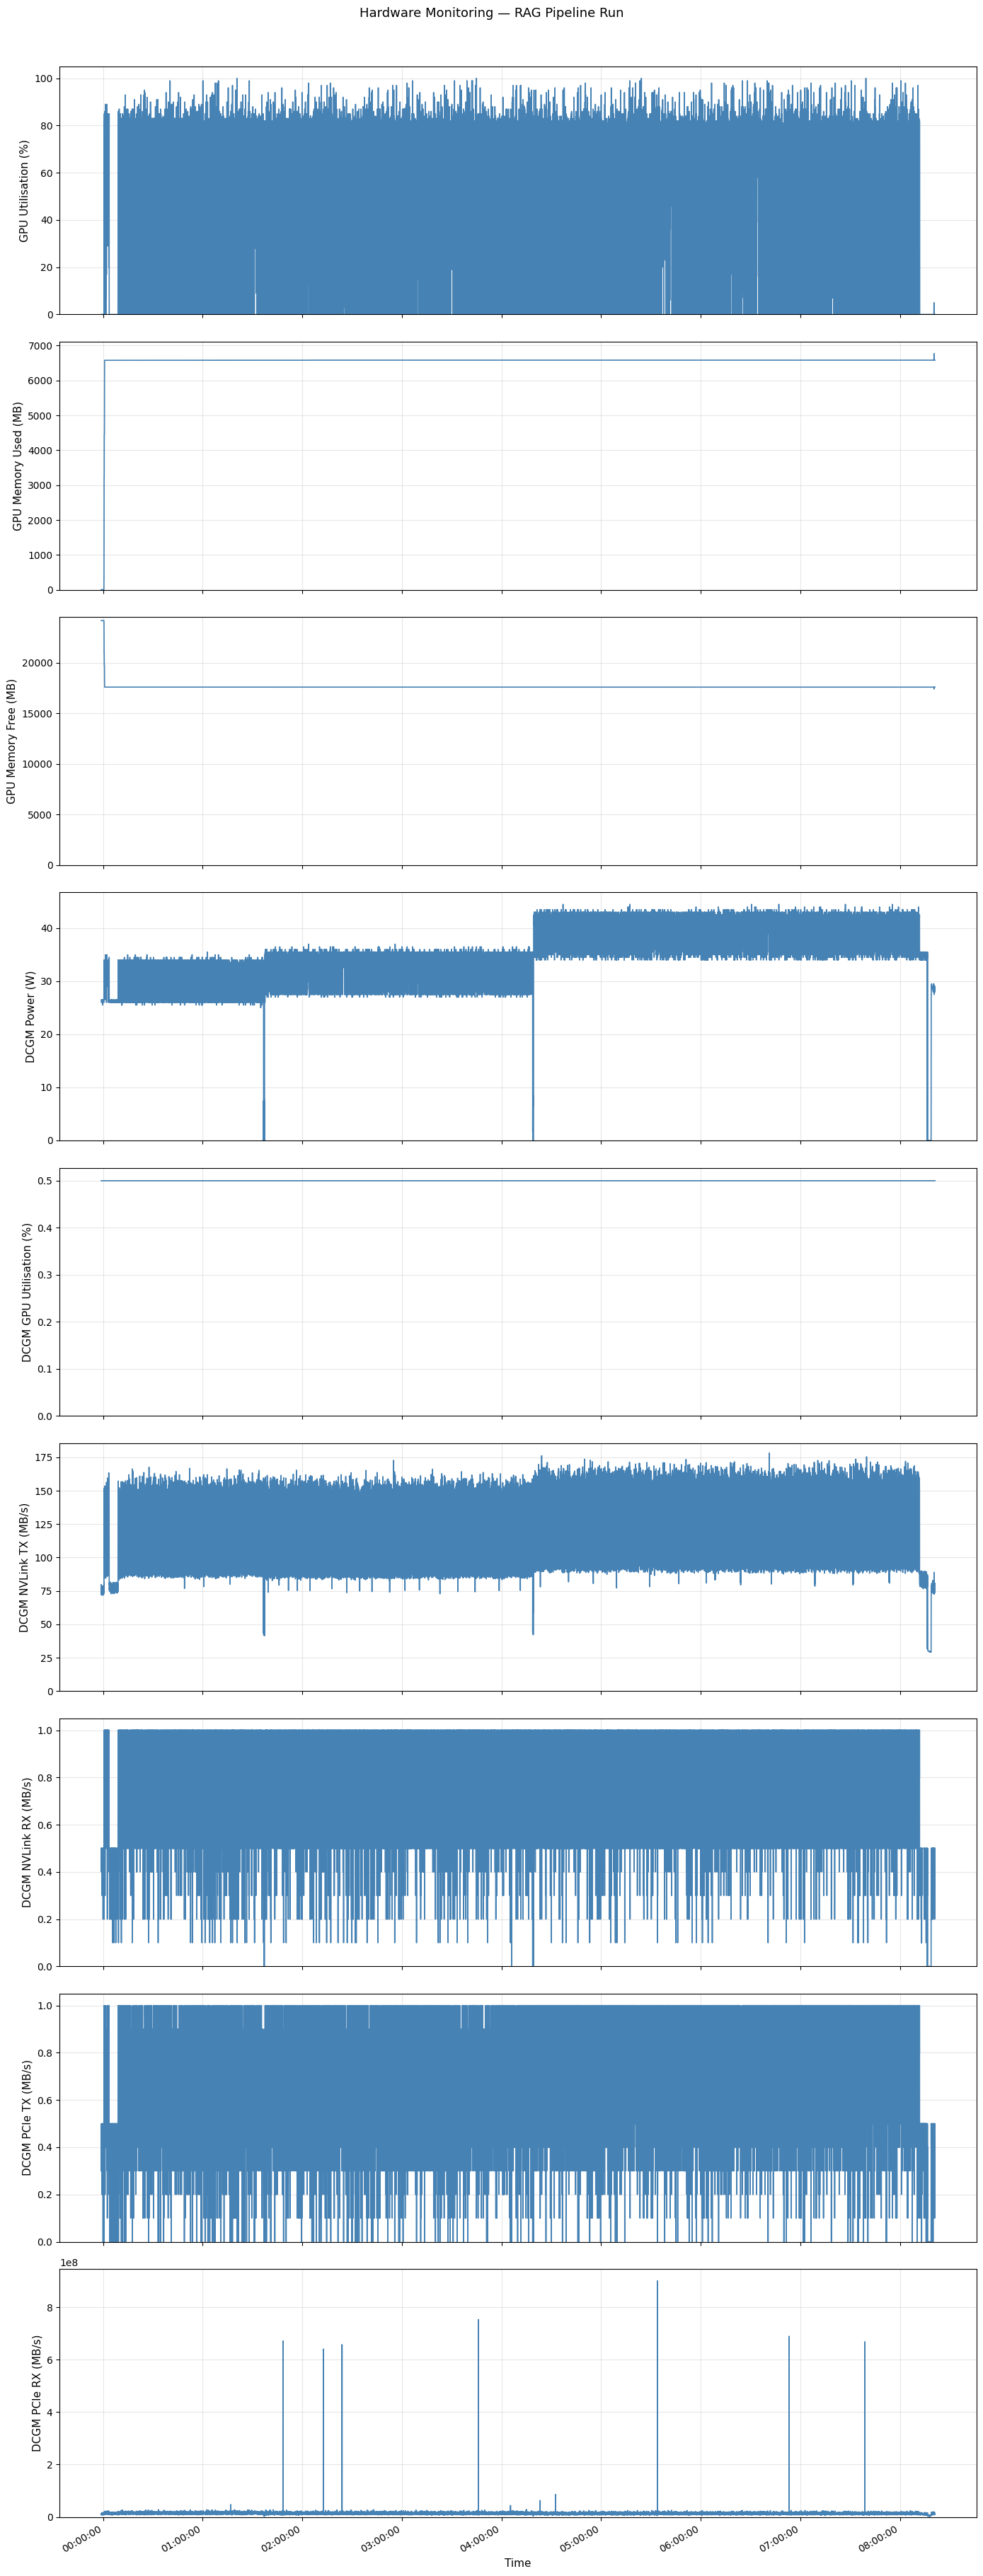

In [6]:
df = load_hardware("../results/hardware_78375.csv")
pipeline_times = None
#pipeline = "results/pipeline_1_20260502_012417.json"
pipeline = None
if pipeline:
    pipeline_times = load_pipeline_times(pipeline)
plot(df, pipeline_times, "plots/hardware_plot.png")